## Load DECTRIS hdf5data into nbed
L. Houben, Weizmann Institute of Science, Oct 2026

In [2]:
%matplotlib ipympl
import numpy as np
import psutil
import matplotlib as mpl
import matplotlib.pyplot as plt
import nbed
import os

### Path to the data
Load DECTRIS frames from a set of hdf5 files, nbed will use the master file and will search autonomously if an em_metadata file is available

In [4]:
# Path definition and filename
path="/Users/houben/Tyche/Scratch/ArinaDemoData/"
filebasename="AS130_0013_master"
filesuffix=".h5"

### Create an instance of the nbed class and load the data

In [5]:
myset=nbed.pyNBED()

In [7]:
args = {'scan_shape': (256,256), 'bin_scan': (2,2), 'bin_det': (1,1)}
myset.LoadFile(path+filebasename+filesuffix, type='DECTRIS',**args)

pyNBED: Loading DETRIS data from /Users/houben/Tyche/Scratch/ArinaDemoData/AS130_0013_master.h5
pyNBED: Loading EM Metadata from - /Users/houben/Tyche/Scratch/ArinaDemoData/AS130_0013_em_metadata.h5
pyNBED: Scan shape array dimensions - (256, 256)
pyNBED: Magnification 20500.0, Camera Length 0.275
Original 4D Shape: (256, 256, 192, 192) (9.00 GB)
Binned 4D Shape:   (128, 128, 192, 192) (4.50 GB)
Available RAM:     17.36 GB
Decompressing and computing binned 4D array...
[########################################] | 100% Completed | 18.24 s
pyNBED: array dimensions: (128, 128, 192, 192)
pyNBED: Preparing reciprocal space sampling grid


### Retrieve calibration data
- create an instance of the calibration manager class
- you will need a calibration file holding the calibration data as a json string
- also, the em_metadata need to be available


In [10]:
# Retrieve calibrations
# Initialize manager
cal_mgr = nbed.MicroscopeCalibrationManager("/Users/houben/MicroscopeCalibrationDB.json")
samp, qsamp = cal_mgr.get_calibration_from_metadata(myset.metadata, type='DECTRIS')

Magnification calibration Value FOV/sampling: 20500.0 -> 5960.0 / 23.28125 (exact_match)
Diffraction calibration Value FOV/sampling: 275.0 -> 18.863400000000002 / 0.09824687500000001 (interpolated)


### Run the Virtual STEM Explorer Utility

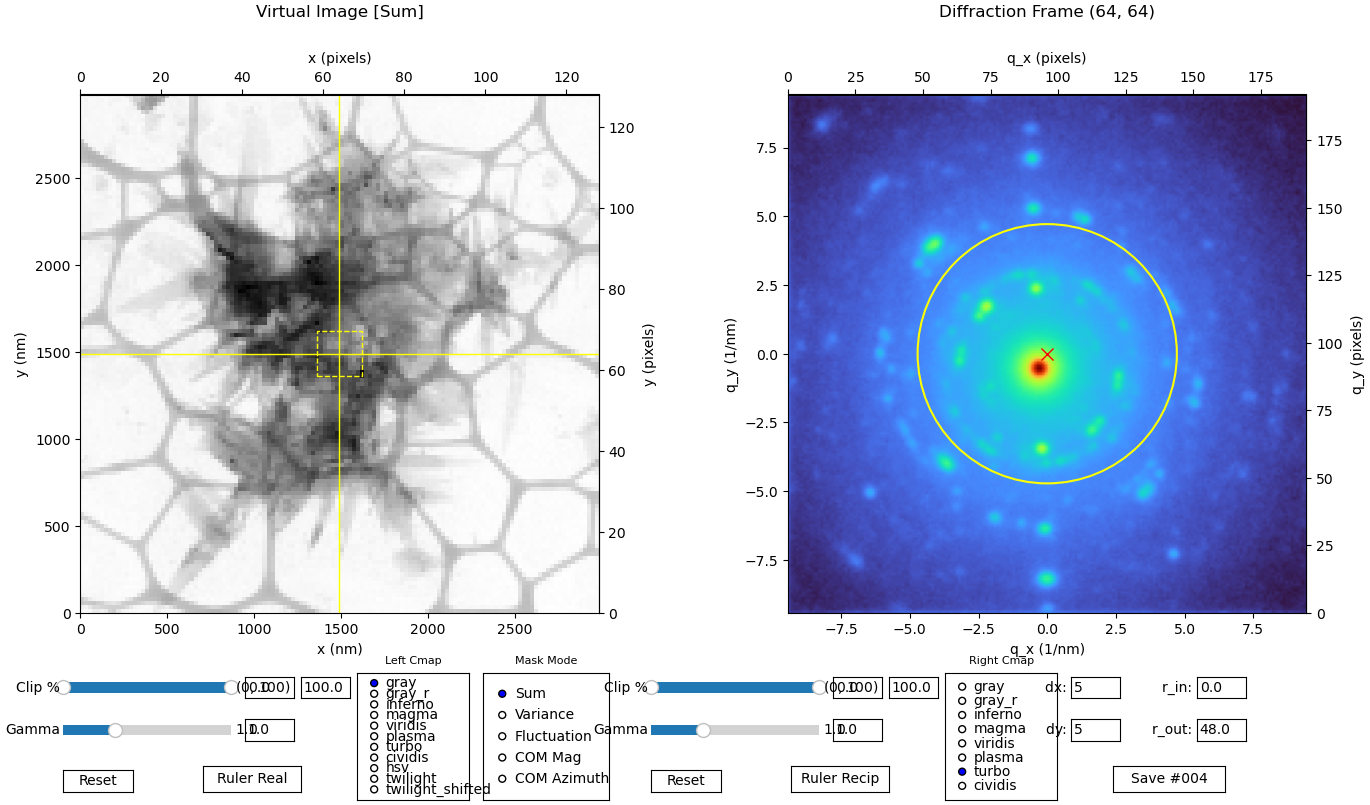

{'y': 64,
 'x': 64,
 'index': 8256,
 'x_phys': 1490.0,
 'y_phys': 1490.0,
 'dx': 5,
 'dy': 5,
 'cqx': 96.0,
 'cqy': 96.0,
 'r_in': 0.0,
 'r_out': 48.0,
 'r_in_phys': 0.0,
 'r_out_phys': 4.7158500000000005,
 'left_cmap': 'gray',
 'right_cmap': 'turbo',
 'mode': 'Sum',
 'ruler_real_dr': 0.0,
 'ruler_recip_dq': 0.0,
 'ruler_recip_d': 0.0}

In [11]:
# Define global container in your notebook
event_data = {'y': 0, 'x': 0, 'index': 0}
nbed.nbedinteractive.VirtualSTEM_Explorer(myset,re_samp=samp, rec_samp=qsamp,target_dict=event_data, save_prefix=path+filebasename+"_export")

### Prepare for Data Reduction by Peak Detection

In [12]:
# retrieve default peak detection parameters for the Dectris ELA detector 
pars=myset.PreparePeakDetectionPars(shortcut='ELA')


In [13]:
# adapt parameters, setting conv2D to False speeds up processing
pars["feature_sz"]=7
pars["feature_noise_sz"]=1.2
pars["feature_minmass"]=60
pars["feature_separation"]=3
pars["feature_threshold"]=7
pars["conv2D"]=False
pars["frame_cmax"]=10.
pars["smooth_sz"]=3

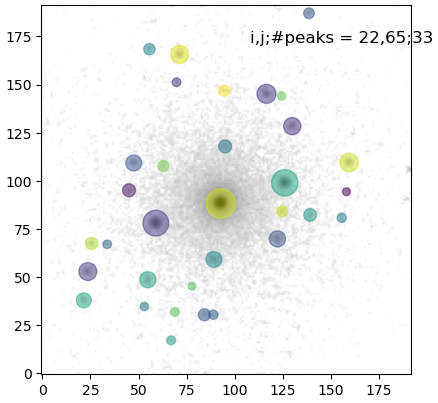

In [14]:
# perform a test run on a single frame
indcs=[event_data["index"]]
framepeaklist=myset.PeakDetection(indcs,params=pars,animate=True,origin='lower')

### Run Peak Detection in all Frames

In [15]:
# run peak search on all frames
# this may take a little while
rows=np.arange(0,myset.dim[0])
cols=np.arange(0,myset.dim[1])
indcs=myset.LinearIndexArray(rows,cols,is_roi=True)
framepeaklist=myset.PeakDetection(indcs,params=pars,animate=False)

Processing Frames : 100%|████████████████████████████████████████| 16384/16384 [01:24<00:00, 193.09it/s]


### Filter Peak List 
- display a pseudo-powder pattern
- display an orientation map

In [16]:
feature_filt={}
feature_filt['massthresh']=150.
feature_filt['qrange']=tuple(np.array([1,100]))

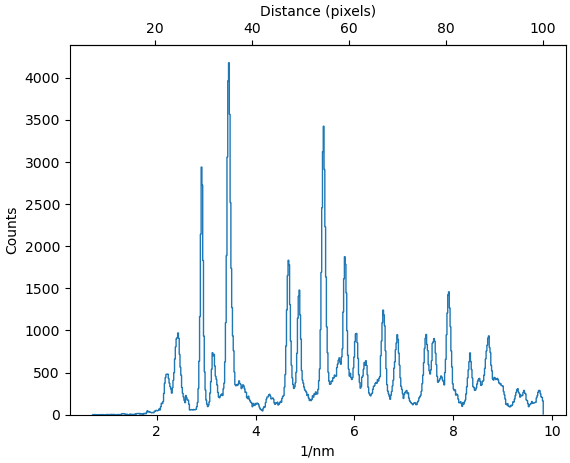

In [17]:
# produce a peak distance histogram - a type of powder diffraction - from all frames
# filter peaks with a raw electron count >= 200
# refine the center for each frame, this produces the sub-pixel precision
(counts,bins)=myset.PeakDistanceHistogram(framepeaklist, refine=True,  pixel_scale=qsamp, unit_label="1/nm",massthresh=feature_filt['massthresh'],qrange=feature_filt['qrange'])

In [20]:
# create an orientation map for a specific range of momentum
qrange=[10,128]
omap, magmap = myset.OrientationMap(framepeaklist, qrange=qrange,massthresh=20,refine=True)

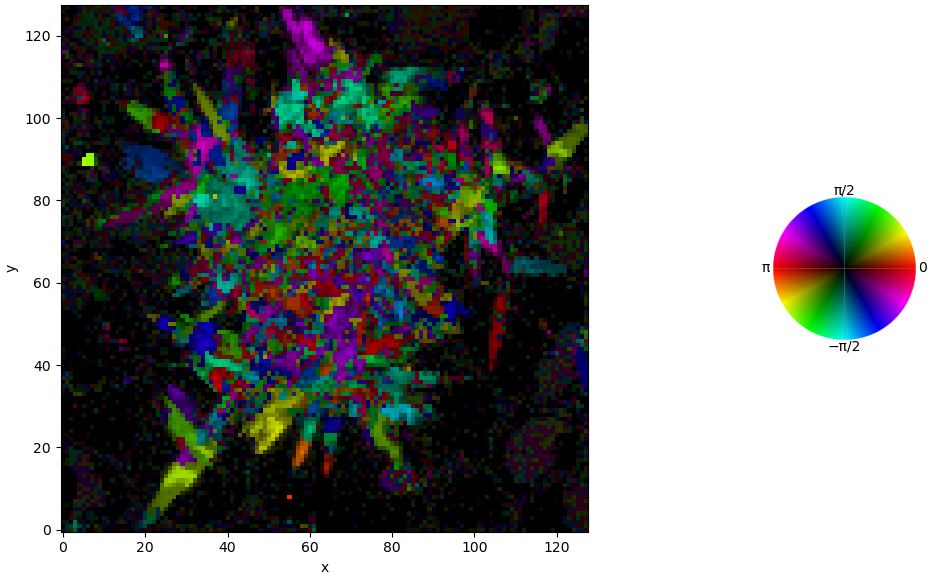

In [21]:
# Plot the orientation data in a hue, saturation, value color encoding
# hue = complex arg
# saturation = constant
# value = magnitude of the reflection, also the square-root or logarithm of it
#vdata=np.sqrt(np.abs(magmap))
vdata=np.abs(magmap)
im=myset.Complex2HSVPlotLgnd(omap, vdata, clip=(None, 1.*np.max(vdata)), larmor=0., multiplicity=2,saturation=1.,origin='lower')